### Enable importing modules from the parent project directory


In [1]:
import sys
import os
sys.path.append(os.path.abspath(".."))  # Adds project root

### Importing necessary libraries

In [2]:
import pandas as pd  # Data manipulation and DataFrame support
import numpy as np  # Numerical computing with arrays
import math  # Basic mathematical functions
import matplotlib.pyplot as plt  # Plotting and visualization
from sklearn.metrics import mean_squared_error, mean_absolute_error  # Evaluation metrics
from statistics import mode  # Compute statistical mode
import folium  # Interactive maps (leaflet.js-based)
from folium.plugins import MarkerCluster  # Cluster markers on maps
from scipy.stats import pearsonr  # Pearson correlation calculation
from sklearn.preprocessing import StandardScaler  # Z-score normalization
from sklearn.preprocessing import MinMaxScaler  # Scale features to 0–1 range
from tqdm import tqdm  # Progress bars for loops
from prophet import Prophet  # Facebook Prophet time series forecasting
import random  # Random number generation
from sklearn.impute import SimpleImputer  # Basic missing value imputation
from typing import Dict  # Type hinting for dictionaries
import seaborn as sns  # Statistical data visualization
from sklearn.impute import SimpleImputer  # (Duplicate) Basic imputation again
from IPython.display import display, HTML  # Pretty HTML display in notebooks
from sklearn.decomposition import PCA  # Principal Component Analysis (dimensionality reduction)
from sklearn.preprocessing import StandardScaler  # (Duplicate) Z-score scaling
from statsmodels.tsa.holtwinters import ExponentialSmoothing  # Time series smoothing & forecasting
from sklearn.ensemble import RandomForestRegressor  # Random Forest for regression tasks
from sklearn.inspection import permutation_importance  # Feature importance via permutation
import warnings  # Control warning messages
warnings.filterwarnings("ignore")  # Suppress warnings (useful in notebooks)
from prophet.plot import plot_plotly, plot_components_plotly  # Plotting Prophet results
from prophet.diagnostics import cross_validation, performance_metrics  # Prophet diagnostics tools

In [3]:
from typing import List, Tuple  # Type hinting for lists and tuples

from Algorithms.CDREC import CDRec  # Collaborative Denoising for matrix completion
from Algorithms.TKCM import TKCM  # Top-k Case Matching (basic version)
from Algorithms.TKCM_Weighted import TKCM_Weighted  # TKCM with similarity-based weighting
from Algorithms.DynaMMO import DynaMMo  # Dynamic Matrix Modeling for time series imputation
from Algorithms.SoftImpute import SoftImpute  # Low-rank matrix completion using soft-thresholding
from Algorithms.SVDImpute import IterativeSVD  # Iterative SVD-based matrix imputation
from Algorithms.trmf import TRMFImputer  # Temporal Regularized Matrix Factorization
from Algorithms.ST_MVL import ST_MVL  # Space-Time Matrix-Vector Learning
from Algorithms.TKCM_PLUS import TKCM_PLUS  # TKCM variant with alpha–beta blending, also using Target series known values to fill the missing values
from Algorithms.TKCM_PRO import TKCM_PRO  # Pro version of TKCM with anchor filtering, here averaging the refrence to fill the missing values


### Loading the Dataset

In [4]:


valley_df = pd.read_csv("D:\\Thesis\\Project\\Data\\valley_data.csv")

# Counting the different types of missingness in the dataset
stats = {
    "Total Rows": len(valley_df),
    "Total Columns": len(valley_df.columns),
    "Zero Values": (valley_df == 0).sum().sum(),
    "NaN Values": valley_df.isna().sum().sum(),
    "Blank Strings": (valley_df == "").sum().sum(),
    "Unknown Strings": (valley_df.applymap(lambda x: isinstance(x, str) and x.strip().lower() == "unknown")).sum().sum()
}

# Return as DataFrame
stats_df = pd.DataFrame(list(stats.items()), columns=["Metric", "Value"])
stats_df


,Metric,Value
0,Total Rows,7079427
1,Total Columns,6
2,Zero Values,1667902
3,NaN Values,0
4,Blank Strings,0
5,Unknown Strings,0


#### Displaying the first 5 rows of the data

In [5]:
valley_df.head()

,station_code,sensor_code,description_it,unit,timestamp,value
0,37100MS,LT,Temperatura dell´aria,°C,2025-01-01 00:00:00,-10.4
1,37100MS,LT,Temperatura dell´aria,°C,2024-12-31 23:30:00,-8.9
2,37100MS,LT,Temperatura dell´aria,°C,2024-12-31 23:00:00,-9.5
3,37100MS,LT,Temperatura dell´aria,°C,2024-12-31 22:30:00,-8.1
4,37100MS,LT,Temperatura dell´aria,°C,2024-12-31 22:00:00,-8.8


### Displaying column-wise metadata


In [6]:
valley_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7079427 entries, 0 to 7079426
Data columns (total 6 columns):
 #   Column          Dtype  
---  ------          -----  
 0   station_code    object 
 1   sensor_code     object 
 2   description_it  object 
 3   unit            object 
 4   timestamp       object 
 5   value           float64
dtypes: float64(1), object(5)
memory usage: 324.1+ MB


### describe() provide us with statistical summary of numeric columns


In [7]:
valley_df.describe()

,value
count,7.079427e+06
mean,1.722966e+02
std,3.336668e+02
min,-9.760000e+01
25%,0.000000e+00
50%,3.600000e+00
75%,1.000000e+02
max,1.474800e+03


In [8]:
# Preview data
print("🔍 Shape:", valley_df.shape)

🔍 Shape: (7079427, 6)


In [9]:
# Check which columns are non-numeric
print("🧠 Columns in the file:\n", valley_df.dtypes)

🧠 Columns in the file:
 station_code       object
sensor_code        object
description_it     object
unit               object
timestamp          object
value             float64
dtype: object


### Checking all the unique sensor codes i have in this dataset

In [10]:
unique_values = valley_df['sensor_code'].unique()
unique_values

array(['LT', 'N', 'WR', 'WG', 'WG.BOE', 'LF', 'LD.RED', 'GS', 'SD', 'HS',
       'W', 'WT'], dtype=object)

### checking unique similar station_codes

In [11]:
unique_values1 = valley_df['station_code'].unique()
unique_values1

array(['37100MS', '20500MS', '19300MS', '80300MS', '50500MS', '34500MS',
       '56900MS', '54500MS', '69900MS', '09700MS', '82200MS', '88820MS',
       '59700MS', '85120MS', '83200MS', '86900MS', '39100MS', '08200MS',
       '23200MS', '47400MS', '86600MS', '37700MS', '74900MS', '89190MS',
       '22210MS', '25900MS', '73500MS', '68600MS', '02200MS', '03100MS',
       '41000MS', '75600MS', '62600MS', '74200MS', '11400MS', '02500MS',
       '33500MS', '44500MS', '06400MS', '65600MS', '24400MS', '43200MS',
       '78305MS', '56500MS', '42700MS', '15800MS', '65350MS', '89950SE',
       '02250SE', '78150SE', '82910MS', '47150SE', '27100MS', '89155SE',
       '89355SE', '85700MS', '89055SE', '42150SE', '39050SE', '79450SE',
       '87300MS', '66500MS', '20910MS', '31410MS', '78110MS', '61300MS',
       '01110MS', '71510MS', '79300MS', '75510SE', '90150SE', '91510MS'],
      dtype=object)

### Looking at the descriptions of the sensor what is meaning of those sensor codes

In [12]:
unique_values2 = valley_df['description_it'].unique()
unique_values2

array(['Temperatura dell´aria', 'Precipitazioni', 'Direzione del vento',
       'Velocità del vento', 'Velocitá raffica', 'Umidità relativa',
       'Pressione atmosferica', 'Radiazione globale ',
       'Durata soleggiamento', 'Altezza neve al suolo',
       'Livello idrometrico', 'Temperatura acqua'], dtype=object)

### checking unit of data values

In [13]:
unique_values3 = valley_df['unit'].unique()
unique_values3

array(['°C', 'mm', '° ', 'm/s', '%', 'hPa', 'W/m²', 's', 'cm'],
      dtype=object)

### looking at unique values

In [14]:
unique_values4 = valley_df['value'].unique()
unique_values4

array([-10.4,  -8.9,  -9.5, ..., 981.9, 855.3, 802.7], shape=(11245,))

### Checking the columns i have and how they pronounced

In [15]:
column_names = list(valley_df.columns)
column_names

['station_code', 'sensor_code', 'description_it', 'unit', 'timestamp', 'value']

### counting the zeroes and sum them 

In [16]:
zero_counts = (valley_df == 0).sum()
print(zero_counts)

station_code            0
sensor_code             0
description_it          0
unit                    0
timestamp               0
value             1667902
dtype: int64


### displaying the values with zeroes

In [17]:
valley_df[valley_df["value"] == 0].head()

,station_code,sensor_code,description_it,unit,timestamp,value
116,37100MS,LT,Temperatura dell´aria,°C,2024-12-29 14:00:00,0.0
338,37100MS,LT,Temperatura dell´aria,°C,2024-12-24 23:00:00,0.0
426,37100MS,LT,Temperatura dell´aria,°C,2024-12-23 03:00:00,0.0
598,37100MS,LT,Temperatura dell´aria,°C,2024-12-19 13:00:00,0.0
637,37100MS,LT,Temperatura dell´aria,°C,2024-12-18 17:30:00,0.0


#### checking if values are numeric, if yes then add percentage to the zeroes and sort them by percentage of zero they contain. 

In [18]:
# Make sure 'value' is numeric
valley_df['value'] = pd.to_numeric(valley_df['value'], errors='coerce')

# Group by sensor_code
zero_stats = (
    valley_df.groupby('sensor_code')
    .agg(
        total_entries=('value', 'count'),
        zero_count=('value', lambda x: (x == 0).sum())
    )
)

# Add percentage of zeros
zero_stats['zero_percentage'] = (zero_stats['zero_count'] / zero_stats['total_entries']) * 100

# Sort by percentage of zero values
zero_stats = zero_stats.sort_values(by='zero_percentage', ascending=False)

print(zero_stats.reset_index())


   sensor_code  total_entries  zero_count  zero_percentage
0            N         585918      565938        96.589967
1           SD         773271      643102        83.166445
2           GS         758400      438331        57.796809
3            W          83263        5222         6.271693
4           LT         889920        7619         0.856144
5           WG         713371        4772         0.668937
6           HS          29182         170         0.582551
7       WG.BOE         713371        2423         0.339655
8           WT          83262          60         0.072062
9           WR         713371         265         0.037148
10          LF         875328           0         0.000000
11      LD.RED         860770           0         0.000000


In [19]:
# Step 1: Select sensor `LF`
lf_df = valley_df[valley_df['sensor_code'] == 'LF'].copy()

In [20]:
# Step 2: Replace `0.0` values with NaN
lf_df.loc[lf_df['value'] == 0.0, 'value'] = np.nan

In [21]:
# Step 3: Pivot to wide format (timestamp × station_code)
lf_df['timestamp'] = pd.to_datetime(lf_df['timestamp'])
pivot_df = lf_df.pivot(index='timestamp', columns='station_code', values='value')

In [22]:
# Step 4: Drop sparse stations (>10% missing)
threshold = 0.9 * len(pivot_df)
pivot_df = pivot_df.dropna(thresh=threshold, axis=1)

In [23]:
# Step 5: Drop rows with any missing values
clean_df = pivot_df.dropna(axis=0)

#### Displaying the clean dataframe to check what i have with me.

In [24]:
clean_df

station_code,01110MS,02200MS,02500MS,03100MS,06400MS,08200MS,09700MS,11400MS,15800MS,19300MS,...,82910MS,83200MS,85120MS,85700MS,86600MS,86900MS,87300MS,88820MS,89190MS,91510MS
timestamp,,,,,,,,,,,,,,,,,,,,,
2023-01-01 00:00:00,99.1,90.4,82.5,86.2,94.8,99.8,92.7,91.6,91.9,90.6,...,93.8,87.7,99.9,96.8,95.8,98.1,97.6,83.5,84.3,99.9
2023-01-01 00:30:00,98.1,90.8,80.8,84.9,97.1,99.8,91.1,92.1,92.7,91.7,...,91.8,87.0,99.9,97.7,94.5,97.0,97.5,82.7,84.3,99.9
2023-01-01 01:00:00,98.0,91.5,81.9,83.5,96.7,99.8,90.0,89.1,92.4,90.1,...,92.1,85.3,99.9,97.1,93.5,98.5,99.7,89.8,81.3,99.9
2023-01-01 01:30:00,99.7,92.6,81.1,85.3,97.7,99.8,89.4,88.5,93.3,89.2,...,95.1,84.2,99.9,98.8,92.5,99.2,96.4,90.6,83.9,99.9
2023-01-01 02:00:00,99.8,94.2,81.9,84.5,95.4,99.8,88.2,86.2,94.2,89.1,...,98.6,88.4,99.9,99.6,94.5,99.0,99.9,90.0,80.9,99.9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-31 22:00:00,54.5,74.4,38.3,53.7,48.4,91.3,64.9,51.1,49.7,89.4,...,84.0,90.2,47.1,100.2,99.6,98.7,53.8,95.8,64.1,96.9
2024-12-31 22:30:00,54.7,75.9,41.8,56.0,46.0,91.3,67.3,51.9,50.2,90.5,...,84.5,88.9,48.7,100.2,99.1,100.0,54.0,99.0,61.4,96.0
2024-12-31 23:00:00,54.7,77.3,39.0,55.8,46.4,92.2,64.2,51.1,51.0,90.4,...,85.7,89.0,48.4,99.7,99.7,100.0,57.7,96.6,63.5,96.1


In [25]:
# Step 6: Pick a target station
target_station = clean_df.columns[2]

#### displaying target station

In [26]:
target_station

'02500MS'

In [27]:
# Step 7: Compute Pearson correlations 
correlations = clean_df.corr()[target_station].drop(index=target_station).sort_values(ascending=False)

### displaying correlations

In [28]:
correlations

station_code
15800MS    0.860133
03100MS    0.856343
06400MS    0.820458
20910MS    0.815276
24400MS    0.812125
71510MS    0.806599
68600MS    0.800845
01110MS    0.791615
20500MS    0.790726
11400MS    0.787193
65600MS    0.757288
02200MS    0.756943
87300MS    0.755742
85120MS    0.755661
78110MS    0.751061
79300MS    0.736962
34500MS    0.730753
75600MS    0.725095
74200MS    0.723658
73500MS    0.720382
66500MS    0.720341
25900MS    0.701794
89190MS    0.688170
82200MS    0.681692
44500MS    0.661228
47400MS    0.660803
78305MS    0.656539
82910MS    0.645984
69900MS    0.640392
50500MS    0.635309
09700MS    0.633138
54500MS    0.627258
61300MS    0.615036
80300MS    0.614604
37700MS    0.610875
08200MS    0.609098
22210MS    0.560592
31410MS    0.544317
42700MS    0.535828
37100MS    0.530221
83200MS    0.519141
62600MS    0.510519
74900MS    0.487708
19300MS    0.482003
23200MS    0.477953
39100MS    0.473874
88820MS    0.465987
86900MS    0.454714
41000MS    0.453751
56500MS

### Plotting the correlation of target series with refrence series

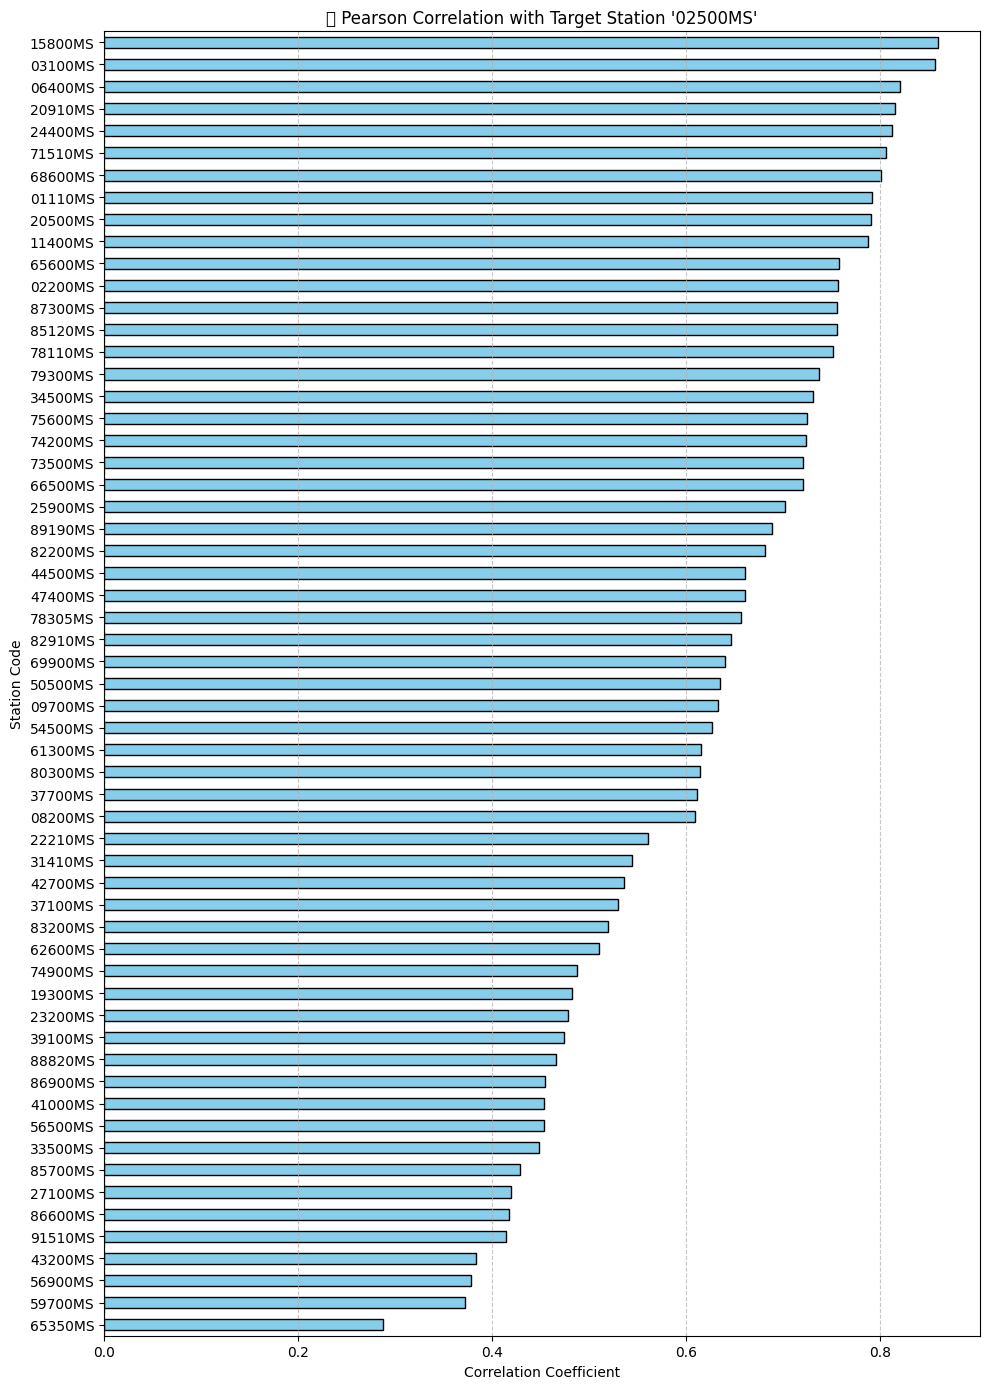

In [29]:
plt.figure(figsize=(10, 14))
correlations.sort_values().plot(kind='barh', color='skyblue', edgecolor='black')

plt.axvline(x=0, color='gray', linestyle='--', linewidth=1)
plt.title("📈 Pearson Correlation with Target Station '02500MS'")
plt.xlabel("Correlation Coefficient")
plt.ylabel("Station Code")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [30]:
# Step 8: Select top 2 correlated reference stations
top_refs = correlations.head(2).index.tolist()
final_df = clean_df[[target_station] + top_refs].copy()

In [31]:
top_refs

['15800MS', '03100MS']

#### Checking the final dataframe

In [32]:
final_df

station_code,02500MS,15800MS,03100MS
timestamp,,,
2023-01-01 00:00:00,82.5,91.9,86.2
2023-01-01 00:30:00,80.8,92.7,84.9
2023-01-01 01:00:00,81.9,92.4,83.5
2023-01-01 01:30:00,81.1,93.3,85.3
2023-01-01 02:00:00,81.9,94.2,84.5
...,...,...,...
2024-12-31 22:00:00,38.3,49.7,53.7
2024-12-31 22:30:00,41.8,50.2,56.0
2024-12-31 23:00:00,39.0,51.0,55.8


In [33]:
# Step 8: Build new DataFrame with target and top 3 references
top_3_refs = correlations.dropna().sort_values(ascending=False).head(3).index.tolist()
selected_stations = [target_station] + top_3_refs
pattern_df = pivot_df[selected_stations].copy()

In [34]:
pattern_df

station_code,02500MS,15800MS,03100MS,06400MS
timestamp,,,,
2023-01-01 00:00:00,82.5,91.9,86.2,94.8
2023-01-01 00:30:00,80.8,92.7,84.9,97.1
2023-01-01 01:00:00,81.9,92.4,83.5,96.7
2023-01-01 01:30:00,81.1,93.3,85.3,97.7
2023-01-01 02:00:00,81.9,94.2,84.5,95.4
...,...,...,...,...
2024-12-31 22:00:00,38.3,49.7,53.7,48.4
2024-12-31 22:30:00,41.8,50.2,56.0,46.0
2024-12-31 23:00:00,39.0,51.0,55.8,46.4


#### Plotting target station with reference stations

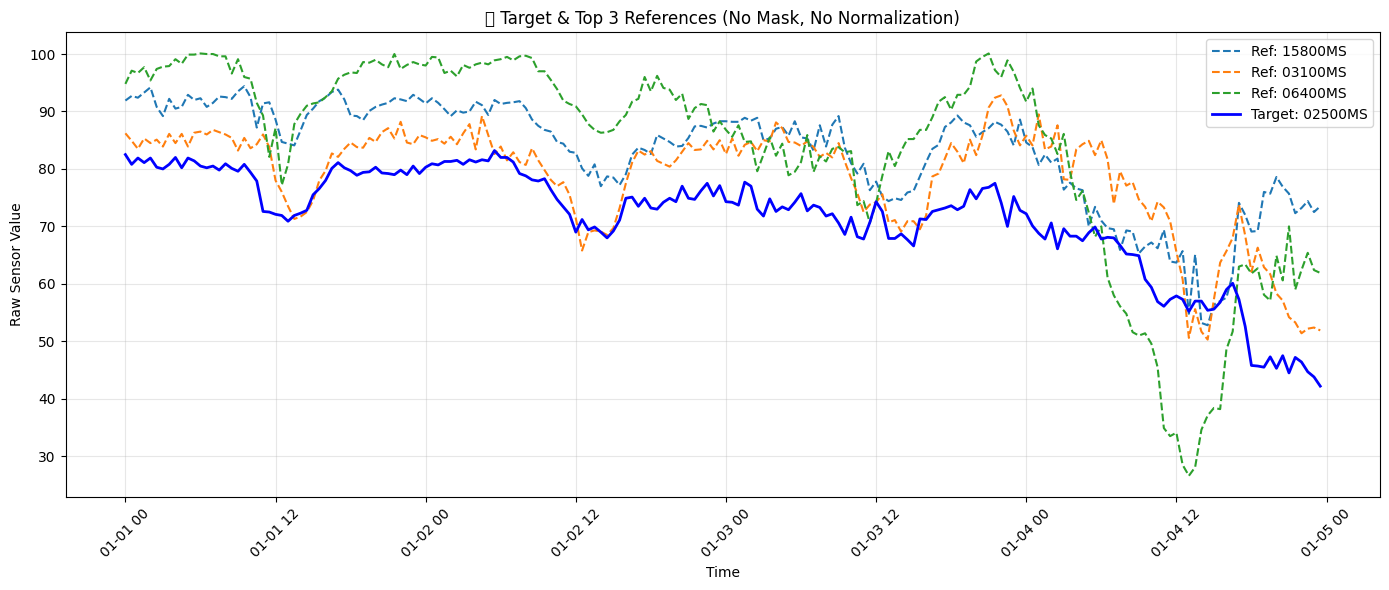

In [35]:
# Define the stations 
target = "02500MS"
references = ["15800MS","03100MS","06400MS"]

# Define time range for plot (e.g., Jan 1 to Jan 4, 2023)
start_time = "2023-01-01"
end_time = "2023-01-04"

# Slicing the DataFrame
plot_df = pattern_df[[target] + references].loc[start_time:end_time].copy()

# Plotting
plt.figure(figsize=(14, 6))

# Plot reference series
for ref in references:
    plt.plot(plot_df.index, plot_df[ref], linestyle='--', label=f"Ref: {ref}")

# Plot target series
plt.plot(plot_df.index, plot_df[target], color='blue', linewidth=2, label=f"Target: {target}")

plt.xlabel("Time")
plt.ylabel("Raw Sensor Value")
plt.title("📍 Target & Top 3 References (No Mask, No Normalization)")
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


# -------------------------------------------
# 🔹 STEP 1: Normalizing the Time Series Data
# -------------------------------------------

In [38]:
from sklearn.preprocessing import StandardScaler

#  Initialize the Scaler
scaler = StandardScaler()

#  Fit the scaler on the full pattern_df and transform it
normalized_array = scaler.fit_transform(pattern_df)

#  Reconstruct a DataFrame with the same shape, columns, and index
normalized_df = pd.DataFrame(
    normalized_array,
    columns=pattern_df.columns,
    index=pattern_df.index
)

# 4️⃣ Print shape and preview
print(" Normalized shape:", normalized_df.shape)
display(normalized_df.head())


 Normalized shape: (14593, 4)


station_code,02500MS,15800MS,03100MS,06400MS
timestamp,,,,
2023-01-01 00:00:00,1.119923,1.189939,0.666856,1.250501
2023-01-01 00:30:00,1.038581,1.225965,0.609234,1.356561
2023-01-01 01:00:00,1.091214,1.212455,0.547179,1.338115
2023-01-01 01:30:00,1.052935,1.252984,0.626964,1.384229
2023-01-01 02:00:00,1.091214,1.293513,0.591504,1.278168


# ---------------------------------------------------------
# 🔹 STEP 2: Defining function to the inject block-missing in the end
# ---------------------------------------------------------

In [39]:


def introduce_block_missing_end(series: pd.Series, block_length: int) -> Tuple[pd.Series, int, int]:
    """
    Introduce a block of NaN values at the end of a time series.

    Parameters:
        series (pd.Series): The original time series (normalized)
        block_length (int): The number of consecutive values to mask from the end

    Returns:
        masked_series (pd.Series): The modified series with NaNs
        start_idx (int): Starting index of the missing block
        end_idx (int): Ending index (exclusive) of the missing block
    """
    ts = series.copy()
    end_idx = len(ts)
    start_idx = end_idx - block_length
    ts[start_idx:end_idx] = np.nan
    return ts, start_idx, end_idx

# Inject blocks of 7 days (168 time points).

# ---------------------------------------------------------
# 🔹 STEP 2b: Applying block-missing to the normalized target series
# ---------------------------------------------------------

In [ ]:
# ---------------------------------------------------------
# 🔹 STEP 2b: Apply block-missing to the normalized target series
# ---------------------------------------------------------

# Define target station (from your pattern_df)
target_station = "02500MS"

# Define block length (e.g. 10 time points ~ 5 hours if half-hourly)
block_length = 721 

# Apply the masking function
masked_target, start_idx, end_idx = introduce_block_missing_end(
    normalized_df[target_station],
    block_length
)

# ✅ Optional: Print info about the block
print(f"🧱 Missing block injected from index {start_idx} to {end_idx - 1}")
print("🕓 Timestamps of missing block:\n", normalized_df.index[start_idx:end_idx])


🧱 Missing block injected from index 13872 to 14592
🕓 Timestamps of missing block:
 DatetimeIndex(['2024-12-17 00:00:00', '2024-12-17 00:30:00',
               '2024-12-17 01:00:00', '2024-12-17 01:30:00',
               '2024-12-17 02:00:00', '2024-12-17 02:30:00',
               '2024-12-17 03:00:00', '2024-12-17 03:30:00',
               '2024-12-17 04:00:00', '2024-12-17 04:30:00',
               ...
               '2024-12-31 19:30:00', '2024-12-31 20:00:00',
               '2024-12-31 20:30:00', '2024-12-31 21:00:00',
               '2024-12-31 21:30:00', '2024-12-31 22:00:00',
               '2024-12-31 22:30:00', '2024-12-31 23:00:00',
               '2024-12-31 23:30:00', '2025-01-01 00:00:00'],
              dtype='datetime64[ns]', name='timestamp', length=721, freq=None)


# ---------------------------------------------------------
# 🔹 STEP 3: Preparing NumPy arrays for imputation and evaluation
# ---------------------------------------------------------

In [41]:
# Extract the reference station names (excluding the target)
reference_stations = [col for col in normalized_df.columns if col != target_station]

#  Get reference matrix as shape (num_refs, time) — transposed
ref_matrix = normalized_df[reference_stations].to_numpy().T  # shape: (num_refs, time)

#  Get the masked target series as array (shape: time,)
masked_target_array = masked_target.to_numpy().copy()

#  Get the original (true) unmasked target series
true_target_array = normalized_df[target_station].to_numpy()

#  Save the index positions of the block-masked values
nan_block_indices = np.arange(start_idx, end_idx)

#  Preview shapes and sanity check
print(" Target shape:", masked_target_array.shape)
print(" Ref matrix shape:", ref_matrix.shape)
print(" Block indices:", nan_block_indices)
print(" Target preview (with NaNs):", masked_target_array[start_idx:end_idx])


 Target shape: (14593,)
 Ref matrix shape: (3, 14593)
 Block indices: [13872 13873 13874 13875 13876 13877 13878 13879 13880 13881 13882 13883
 13884 13885 13886 13887 13888 13889 13890 13891 13892 13893 13894 13895
 13896 13897 13898 13899 13900 13901 13902 13903 13904 13905 13906 13907
 13908 13909 13910 13911 13912 13913 13914 13915 13916 13917 13918 13919
 13920 13921 13922 13923 13924 13925 13926 13927 13928 13929 13930 13931
 13932 13933 13934 13935 13936 13937 13938 13939 13940 13941 13942 13943
 13944 13945 13946 13947 13948 13949 13950 13951 13952 13953 13954 13955
 13956 13957 13958 13959 13960 13961 13962 13963 13964 13965 13966 13967
 13968 13969 13970 13971 13972 13973 13974 13975 13976 13977 13978 13979
 13980 13981 13982 13983 13984 13985 13986 13987 13988 13989 13990 13991
 13992 13993 13994 13995 13996 13997 13998 13999 14000 14001 14002 14003
 14004 14005 14006 14007 14008 14009 14010 14011 14012 14013 14014 14015
 14016 14017 14018 14019 14020 14021 14022 14023 14024

In [42]:
print(type(masked_target_array), masked_target_array.shape)


<class 'numpy.ndarray'> (14593,)


# -----------------------------------------------
# 🔹 STEP 4.1: Setting safe parameters for all models
# -----------------------------------------------

In [43]:
k = 5  # number of top matching sequences (for TKCMs)
l = 4  # sliding window size
rank = max(1, min(ref_matrix.shape[0] - 1, 2))  # safe low-rank dimension for SVD, TRMF


### --- Basic Imputers --

In [45]:
from sklearn.impute import SimpleImputer

# --- Basic Imputers ---

class ZeroImputer:
    def fit_transform(self, X):
        X = X.copy()
        X[np.isnan(X)] = 0
        return X


class MinImputer:
    def fit_transform(self, X):
        fill_value = np.nanmin(X[~np.isnan(X)])
        imp = SimpleImputer(strategy='constant', fill_value=fill_value)
        return imp.fit_transform(X)

class InterpolationImputer:
    def fit_transform(self, X):
        return pd.DataFrame(X).interpolate(method='linear', axis=0, limit_direction='both').values


# -----------------------------------------------
# 🔹 STEP 4.2: Applying each model with correct usage
# -----------------------------------------------

In [46]:


# Stack the masked target (first row) + full reference matrix (rest)
X_stacked = np.vstack([masked_target_array, ref_matrix])

# TKCM
tkcm = TKCM(k=k, l=l)
tkcm_imputed = tkcm.impute(masked_target_array.copy(), offset=start_idx, ref_ts=ref_matrix)

#  TKCM_PLUS
tkcm_plus = TKCM_PLUS(k=k, l=l, alpha=0.5, beta=0.5)
tkcm_plus_imputed = tkcm_plus.impute(masked_target_array.copy(), offset=start_idx, ref_ts=ref_matrix)

#  TKCM_Weighted
tkcm_w = TKCM_Weighted(k=k, l=l)
tkcm_weighted_imputed = tkcm_w.impute(masked_target_array.copy(), offset=start_idx, ref_ts=ref_matrix)

#  TKCM_PRO
tkcm_pro = TKCM_PRO(k=k, l=l)
tkcm_pro_imputed = tkcm_pro.impute(masked_target_array.copy(), offset=start_idx, ref_ts=ref_matrix)


# CDRec
cdrec = CDRec(rank=rank)
cdrec_imputed = cdrec.impute(X_stacked.copy())[0]  # Only return target row

#  DynaMMo
dynammo = DynaMMo(latent_dim=rank)
dynammo_imputed = dynammo.fit_transform(X_stacked.copy())[0]

#  SoftImpute
soft = SoftImpute(max_rank=rank)
soft_imputed = soft.fit_transform(X_stacked.copy())[0]

#  IterativeSVD
svd = IterativeSVD(rank=rank)
svd_imputed = svd.fit_transform(X_stacked.copy())[0]

#  ST_MVL
st_mvl = ST_MVL()
st_mvl_imputed = st_mvl.impute(X_stacked.copy())[0]

#  TRMF
trmf = TRMFImputer(rank=rank)
trmf_imputed = trmf.fit_transform(X_stacked.copy())[0]

#  Zero Imputer
zero_imputer = ZeroImputer()
zero_imputed = zero_imputer.fit_transform(X_stacked.copy())[0]

#  Min Imputer
min_imputer = MinImputer()
min_imputed = min_imputer.fit_transform(X_stacked.copy())[0]

#  Interpolation Imputer
interp_imputer = InterpolationImputer()
interp_imputed = interp_imputer.fit_transform(X_stacked.copy())[0]


In [47]:
# In TKCM imputation loop
missing_indices = np.where(np.isnan(masked_target_array))[0]

for offset in missing_indices:
    imputed_series = tkcm.impute(masked_target_array.copy(), offset=offset, ref_ts=ref_matrix)
    print(f"Offset {offset} → Imputed value = {imputed_series[offset]}")


Offset 2140 → Imputed value = -1.492608975643674
Offset 2141 → Imputed value = -1.5835212708512756
Offset 13872 → Imputed value = -0.4725306480251329
Offset 13873 → Imputed value = -0.21701924991534724
Offset 13874 → Imputed value = -0.6275600356423061
Offset 13875 → Imputed value = -0.5404756265487087
Offset 13876 → Imputed value = -0.4285632794776825
Offset 13877 → Imputed value = -0.8858890265739958
Offset 13878 → Imputed value = -0.8581368522474649
Offset 13879 → Imputed value = -0.7940197598378933
Offset 13880 → Imputed value = -0.8045464466514052
Offset 13881 → Imputed value = -0.3185115537000597
Offset 13882 → Imputed value = -0.43239116559168683
Offset 13883 → Imputed value = -0.7538269556408486
Offset 13884 → Imputed value = -0.5213361959786874
Offset 13885 → Imputed value = -0.44764938828410505
Offset 13886 → Imputed value = -0.5577011140617281
Offset 13887 → Imputed value = -0.4477027100477039
Offset 13888 → Imputed value = -0.27645812820961135
Offset 13889 → Imputed value =

# ---------------------------------------------------------
# 🔹 STEP 5: Evaluating all imputation methods (END Block)
# ---------------------------------------------------------

In [48]:
results_block = []

# 🎯 True values for the missing block
true_vals = true_target_array[start_idx:end_idx]
missing_indices = np.arange(start_idx, end_idx)

# ✅ Helper to evaluate predictions against true values

def evaluate_direct(name, imputed_array):
    try:
        predicted = imputed_array[start_idx:end_idx]
        
        # Core Errors
        mae = np.mean(np.abs(predicted - true_vals))
        rmse = np.sqrt(np.mean((predicted - true_vals) ** 2))
        me = np.mean(predicted - true_vals)  # Mean Error (signed)

        # Bias-Variance
        bias = np.mean(predicted) - np.mean(true_vals)
        bias_sq = bias ** 2
        variance = np.mean((predicted - np.mean(predicted)) ** 2)

        results_block.append({
            "Method": name,
            "MAE": round(mae, 4),
            "RMSE": round(rmse, 4),
            "ME": round(me, 4),
            "Bias^2": round(bias_sq, 4),
            "Variance": round(variance, 4),
            "First Imputed": round(predicted[0], 4),
            "Last Imputed": round(predicted[-1], 4),
            "First True": round(true_vals[0], 4),
            "Last True": round(true_vals[-1], 4),
            "Missing Block": "END"
        })
    except Exception as e:
        results_block.append({
            "Method": name,
            "MAE": "NaN",
            "RMSE": "NaN",
            "ME": "NaN",
            "Bias^2": "NaN",
            "Variance": "NaN",
            "First Imputed": "NaN",
            "Last Imputed": "NaN",
            "First True": round(true_vals[0], 4),
            "Last True": round(true_vals[-1], 4),
            "Missing Block": "END"
        })

# ✅ TKCM (loop over all missing indices)
try:
    tkcm_imputed = masked_target_array.copy()
    for offset in missing_indices:
        tkcm_imputed = TKCM(k=k, l=l).impute(tkcm_imputed, offset=offset, ref_ts=ref_matrix)
    evaluate_direct("TKCM", tkcm_imputed)
except Exception as e:
    print(" TKCM failed:", e)
    evaluate_direct("TKCM", np.full_like(true_vals, np.nan))
    
# ✅ TKCM_PLUS (loop over all missing indices)
try:
    tkcm_plus_imputed = masked_target_array.copy()
    for offset in missing_indices:
        tkcm_plus_imputed = TKCM_PLUS(k=k, l=l, alpha=0.5, beta=0.5).impute(
            tkcm_plus_imputed, offset=offset, ref_ts=ref_matrix
        )
    evaluate_direct("TKCM_PLUS", tkcm_plus_imputed)
except Exception as e:
    print(" TKCM_PLUS failed:", e)
    evaluate_direct("TKCM_PLUS", np.full_like(true_vals, np.nan))


# ✅ TKCM_Weighted (loop over all missing indices)
try:
    tkcm_weighted_imputed = masked_target_array.copy()
    for offset in missing_indices:
        tkcm_weighted_imputed = TKCM_Weighted(k=k, l=l).impute(tkcm_weighted_imputed, offset=offset, ref_ts=ref_matrix)
    evaluate_direct("TKCM_Weighted", tkcm_weighted_imputed)
except Exception as e:
    print(" TKCM_Weighted failed:", e)
    evaluate_direct("TKCM_Weighted", np.full_like(true_vals, np.nan))
    
# ✅ TKCM_PRO (loop over all missing indices)
try:
    tkcm_pro_imputed = masked_target_array.copy()
    for offset in missing_indices:
        tkcm_pro_imputed = TKCM_PRO(k=k, l=l).impute(
            tkcm_pro_imputed, offset=offset, ref_ts=ref_matrix
        )
    evaluate_direct("TKCM_PRO", tkcm_pro_imputed)
except Exception as e:
    print(" TKCM_PRO failed:", e)
    evaluate_direct("TKCM_PRO", np.full_like(true_vals, np.nan))
    



# ✅ Other models (no change needed)
evaluate_direct("CDRec", cdrec_imputed)
evaluate_direct("DynaMMo", dynammo_imputed)
evaluate_direct("SoftImpute", soft_imputed)
evaluate_direct("SVDImpute", svd_imputed)

# ✅ ST_MVL — remove NaNs from references
try:
    X_stmv = X_stacked.copy()
    X_stmv[1:, :] = np.nan_to_num(X_stmv[1:, :])
    st_mvl_model = ST_MVL()
    st_mvl_imputed = st_mvl_model.impute(X_stmv)[0]
    evaluate_direct("ST_MVL", st_mvl_imputed)
except Exception as e:
    print(" ST_MVL failed:", e)
    evaluate_direct("ST_MVL", np.full_like(true_vals, np.nan))

# ✅ TRMF — fixed implementation
try:
    X_trmf_input = X_stacked.T.copy()
    observed_mask = ~np.isnan(X_stacked.T)
    X_trmf_input = np.nan_to_num(X_trmf_input, nan=0.0).astype(np.float64)
    trmf_model = TRMFImputer(rank=rank, lag_idx=[1, 2, 3])
    trmf_model.fit(X_trmf_input, observed_mask)
    X_trmf_output = trmf_model.transform()
    trmf_imputed = X_trmf_output[:, 0]
    evaluate_direct("TRMF", trmf_imputed)
except Exception as e:
    print(" TRMF failed:", e)
    evaluate_direct("TRMF", np.full_like(true_vals, np.nan))
    
evaluate_direct("Zero", zero_imputed)
evaluate_direct("Min", min_imputed)
evaluate_direct("Interpolation", interp_imputed)


# ✅ Final Results Display
results_df = pd.DataFrame(results_block)
display(results_df.style.background_gradient(cmap="YlGnBu", subset=["MAE", "RMSE", "ME", "Bias^2", "Variance"]))


,Method,MAE,RMSE,ME,Bias^2,Variance,First Imputed,Last Imputed,First True,Last True,Missing Block
0,TKCM,0.369600,0.450600,0.275400,0.075800,0.431100,-0.472500,-0.755700,-0.803600,-0.746200,END
1,TKCM_PLUS,0.856800,0.951300,0.604700,0.365700,0.002600,-0.577700,0.000000,-0.803600,-0.746200,END
2,TKCM_Weighted,0.368700,0.449500,0.276300,0.076400,0.433800,-0.471300,-0.735700,-0.803600,-0.746200,END
3,TKCM_PRO,1.478200,1.655700,-0.627700,0.394000,4.751700,-1.808100,-2.407500,-0.803600,-0.746200,END
4,CDRec,0.292300,0.381500,0.190400,0.036300,0.546400,-0.518500,-0.789700,-0.803600,-0.746200,END
5,DynaMMo,0.291700,0.381300,0.189300,0.035800,0.549700,-0.520800,-0.791700,-0.803600,-0.746200,END
6,SoftImpute,0.296600,0.382300,0.198700,0.039500,0.522700,-0.512800,-0.774300,-0.803600,-0.746200,END
7,SVDImpute,0.291000,0.381300,0.187800,0.035300,0.553700,-0.520900,-0.794600,-0.803600,-0.746200,END
8,ST_MVL,0.396200,0.531800,0.125900,0.015800,0.744200,-0.866100,-0.990600,-0.803600,-0.746200,END
9,TRMF,0.638400,0.708100,0.463900,0.215200,0.066900,-0.226500,-0.251900,-0.803600,-0.746200,END


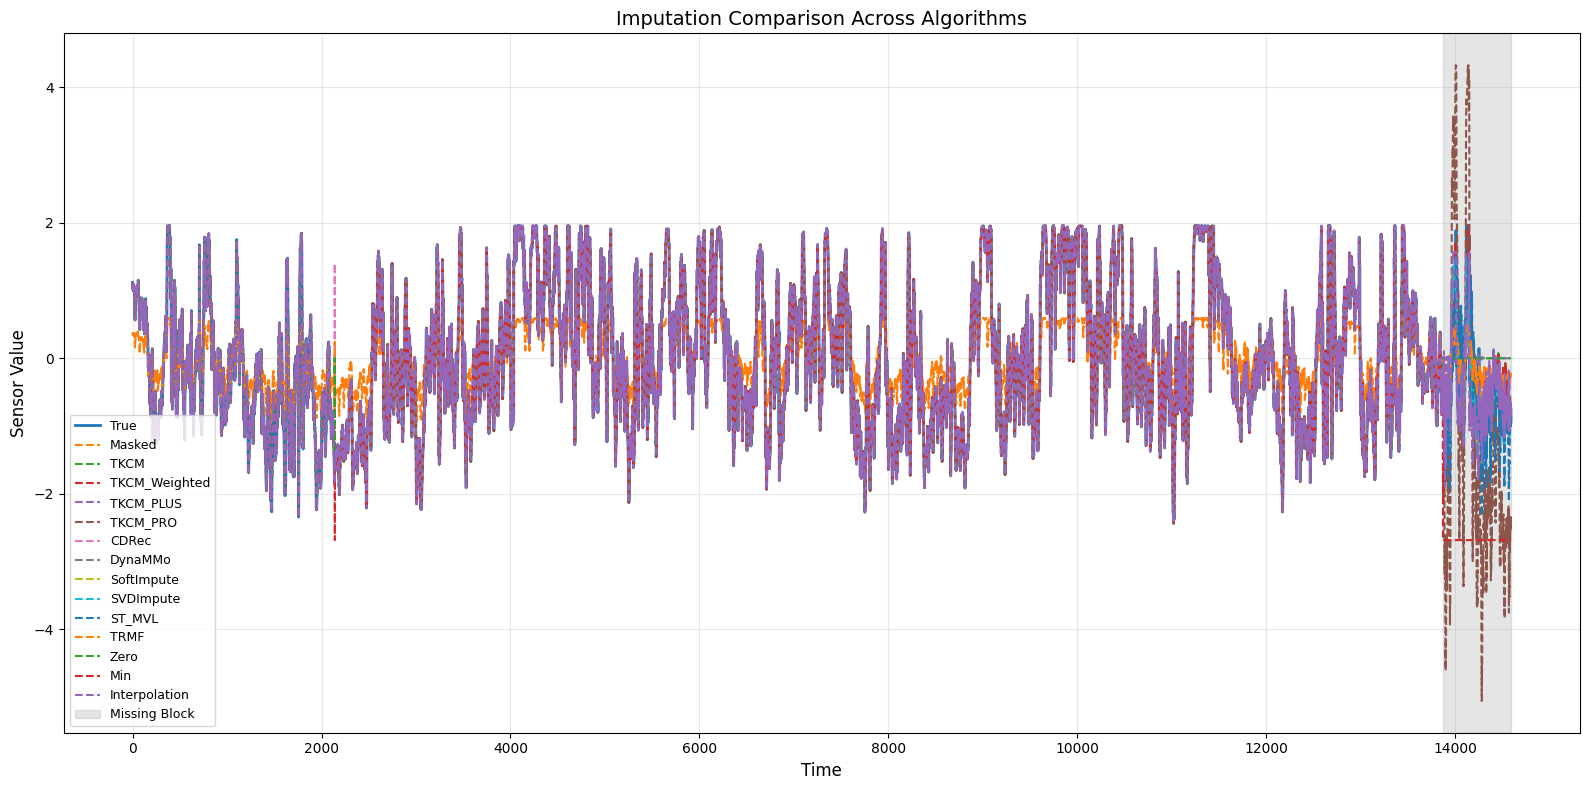

In [ ]:
# ---------------------------------------------------------
# 📊 Plot Imputation Comparison Across Algorithms
# ---------------------------------------------------------

# Build dictionary of series (true + masked + all imputations)
imputed_data = {
    "True": true_target_array,
    "Masked": masked_target_array,
    "TKCM": tkcm_imputed,
    "TKCM_Weighted": tkcm_weighted_imputed,
    "TKCM_PLUS": tkcm_plus_imputed,
    "TKCM_PRO": tkcm_pro_imputed,
    "CDRec": cdrec_imputed,
    "DynaMMo": dynammo_imputed,
    "SoftImpute": soft_imputed,
    "SVDImpute": svd_imputed,
    "ST_MVL": st_mvl_imputed,
    "TRMF": trmf_imputed,
    "Zero": zero_imputed,
    "Min": min_imputed,
    "Interpolation": interp_imputed
}

# Create time axis from dataframe index
time = np.arange(len(true_target_array))

# Plotting
fig, ax = plt.subplots(figsize=(16, 8))

for method, series in imputed_data.items():
    linestyle = "-" if method == "True" else "--"
    linewidth = 2 if method == "True" else 1.5
    ax.plot(time, series, label=method, linestyle=linestyle, linewidth=linewidth)

# Highlight missing block
ax.axvspan(start_idx, end_idx, color="gray", alpha=0.2, label="Missing Block")

ax.set_title("Imputation Comparison Across Algorithms", fontsize=14)
ax.set_xlabel("Time", fontsize=12)
ax.set_ylabel("Sensor Value", fontsize=12)
ax.grid(True, alpha=0.3)
ax.legend(loc="best", fontsize=9)
fig.tight_layout()


import os

# Ensure output folder exists
os.makedirs("plots", exist_ok=True)

# Save high-resolution PDF & PNG
fig.savefig("plots/valley_end_block_comparison.pdf", format="pdf", dpi=300, bbox_inches="tight")
fig.savefig("plots/valley_end_block_comparison.png", format="png", dpi=300, bbox_inches="tight")

plt.show()


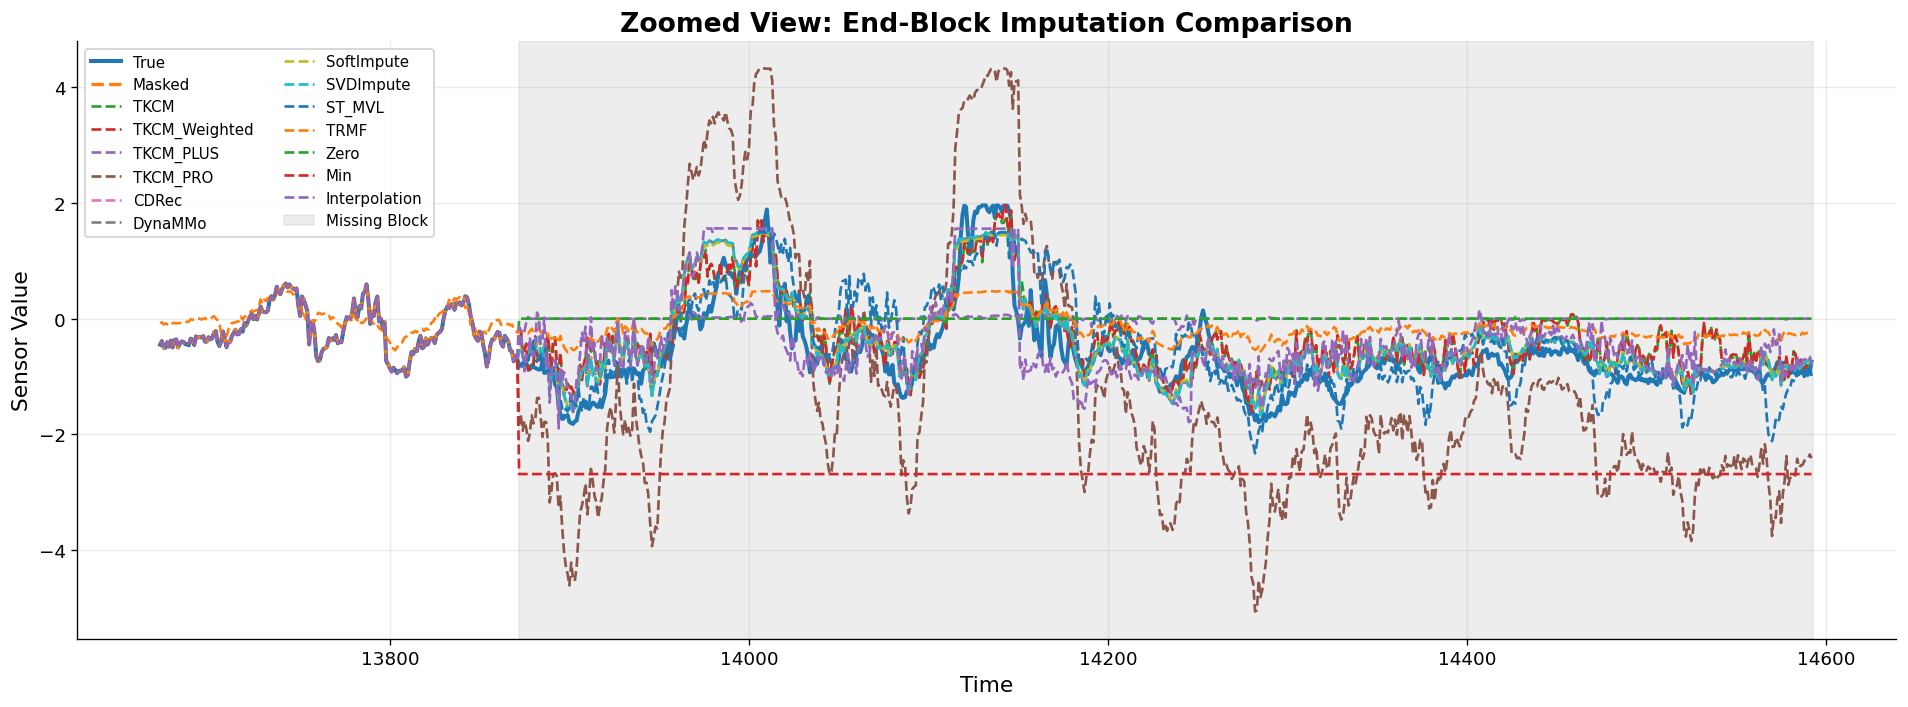

In [ ]:
from matplotlib.ticker import MaxNLocator

def plot_zoom_last_block(true_target_array,
                         masked_target_array,
                         series_dict,
                         start_idx, end_idx,
                         pad=200,
                         out_base="plots/valley_end_block_zoom"):
    """
    Zooms into the missing block at the end of the series.
    - series_dict: {"MethodName": imputed_array, ...} (no True/Masked in dict)
    - pad: how many points of context to show before the block
    """
    os.makedirs(os.path.dirname(out_base), exist_ok=True)

    # window indices (safe bounds)
    n = len(true_target_array)
    i0 = max(0, start_idx - pad)
    i1 = min(n, end_idx + pad)

    t = np.arange(i0, i1)

    fig, ax = plt.subplots(figsize=(16, 6))
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.yaxis.set_major_locator(MaxNLocator(nbins=6))
    ax.grid(True, alpha=0.25)

    # main series
    ax.plot(t, true_target_array[i0:i1], label="True", linewidth=2.4)
    ax.plot(t, masked_target_array[i0:i1], "--", label="Masked", linewidth=2.0)

    # imputations
    for name, arr in series_dict.items():
        ax.plot(t, arr[i0:i1], "--", linewidth=1.6, label=name)

    # highlight the missing block
    ax.axvspan(start_idx, end_idx, color="0.8", alpha=0.35, label="Missing Block")

    ax.set_title("Zoomed View: End-Block Imputation Comparison")
    ax.set_xlabel("Time")
    ax.set_ylabel("Sensor Value")

    ax.legend(loc="upper left", ncol=2, frameon=True, framealpha=0.9, fontsize=9)
    fig.tight_layout()

    fig.savefig(f"{out_base}.pdf")
    fig.savefig(f"{out_base}.png", dpi=300)
    plt.show()
    plt.close(fig)

# call with your arrays
series_dict_zoom = {
    "TKCM": tkcm_imputed,
    "TKCM_Weighted": tkcm_weighted_imputed,
    "TKCM_PLUS": tkcm_plus_imputed,
    "TKCM_PRO": tkcm_pro_imputed,
    "CDRec": cdrec_imputed,
    "DynaMMo": dynammo_imputed,
    "SoftImpute": soft_imputed,
    "SVDImpute": svd_imputed,
    "ST_MVL": st_mvl_imputed,
    "TRMF": trmf_imputed,
    "Zero": zero_imputed,
    "Min": min_imputed,
    "Interpolation": interp_imputed,
}

plot_zoom_last_block(
    true_target_array=true_target_array,
    masked_target_array=masked_target_array,
    series_dict=series_dict_zoom,
    start_idx=start_idx,
    end_idx=end_idx,
    pad=200,  # adjust for more/less context
    out_base="plots/valley_end_block_zoom"
)


In [50]:
# Check the shape of each series in imputed_data to find the mismatch
series_shapes = {k: np.array(v).shape for k, v in imputed_data.items()}
series_shapes_df = pd.DataFrame(list(series_shapes.items()), columns=["Method", "Shape"])

series_shapes_df

,Method,Shape
0,True,"(100,)"
1,Masked,"(100,)"
2,TKCM,"(100,)"
3,TKCM_Weighted,"(100,)"
4,TKCM_PLUS,"(100,)"
5,TKCM_PRO,"(100,)"
6,CDRec,"(100,)"
7,DynaMMo,"(100,)"
8,SoftImpute,"(100,)"
9,SVDImpute,"(100,)"


In [54]:
linestyles = {
    "TKCM": "-",
    "TKCM_Weighted": "-.",
    "TKCM_PLUS": "-",
    "TKCM_PRO": "-.",
    "CDRec": "--",
    "DynaMMo": "--",
    "SoftImpute": "--",
    "SVDImpute": "--",
    "ST_MVL": "-",
    "TRMF": "--",
    "True": "-",
    "Masked": ":"
}

colors = {
    "TKCM": "#1f77b4",
    "TKCM_Weighted": "#ff7f0e",
    "TKCM_PLUS": "#8c564b",
    "TKCM_PRO": "#7f7f7f",
    "CDRec": "#17becf",
    "DynaMMo": "#1a55FF",
    "SoftImpute": "#FF55AA",
    "SVDImpute": "#FFAA00",
    "ST_MVL": "#66c2a5",
    "TRMF": "#a65628",
    "True": "black",
    "Masked": "red"
}


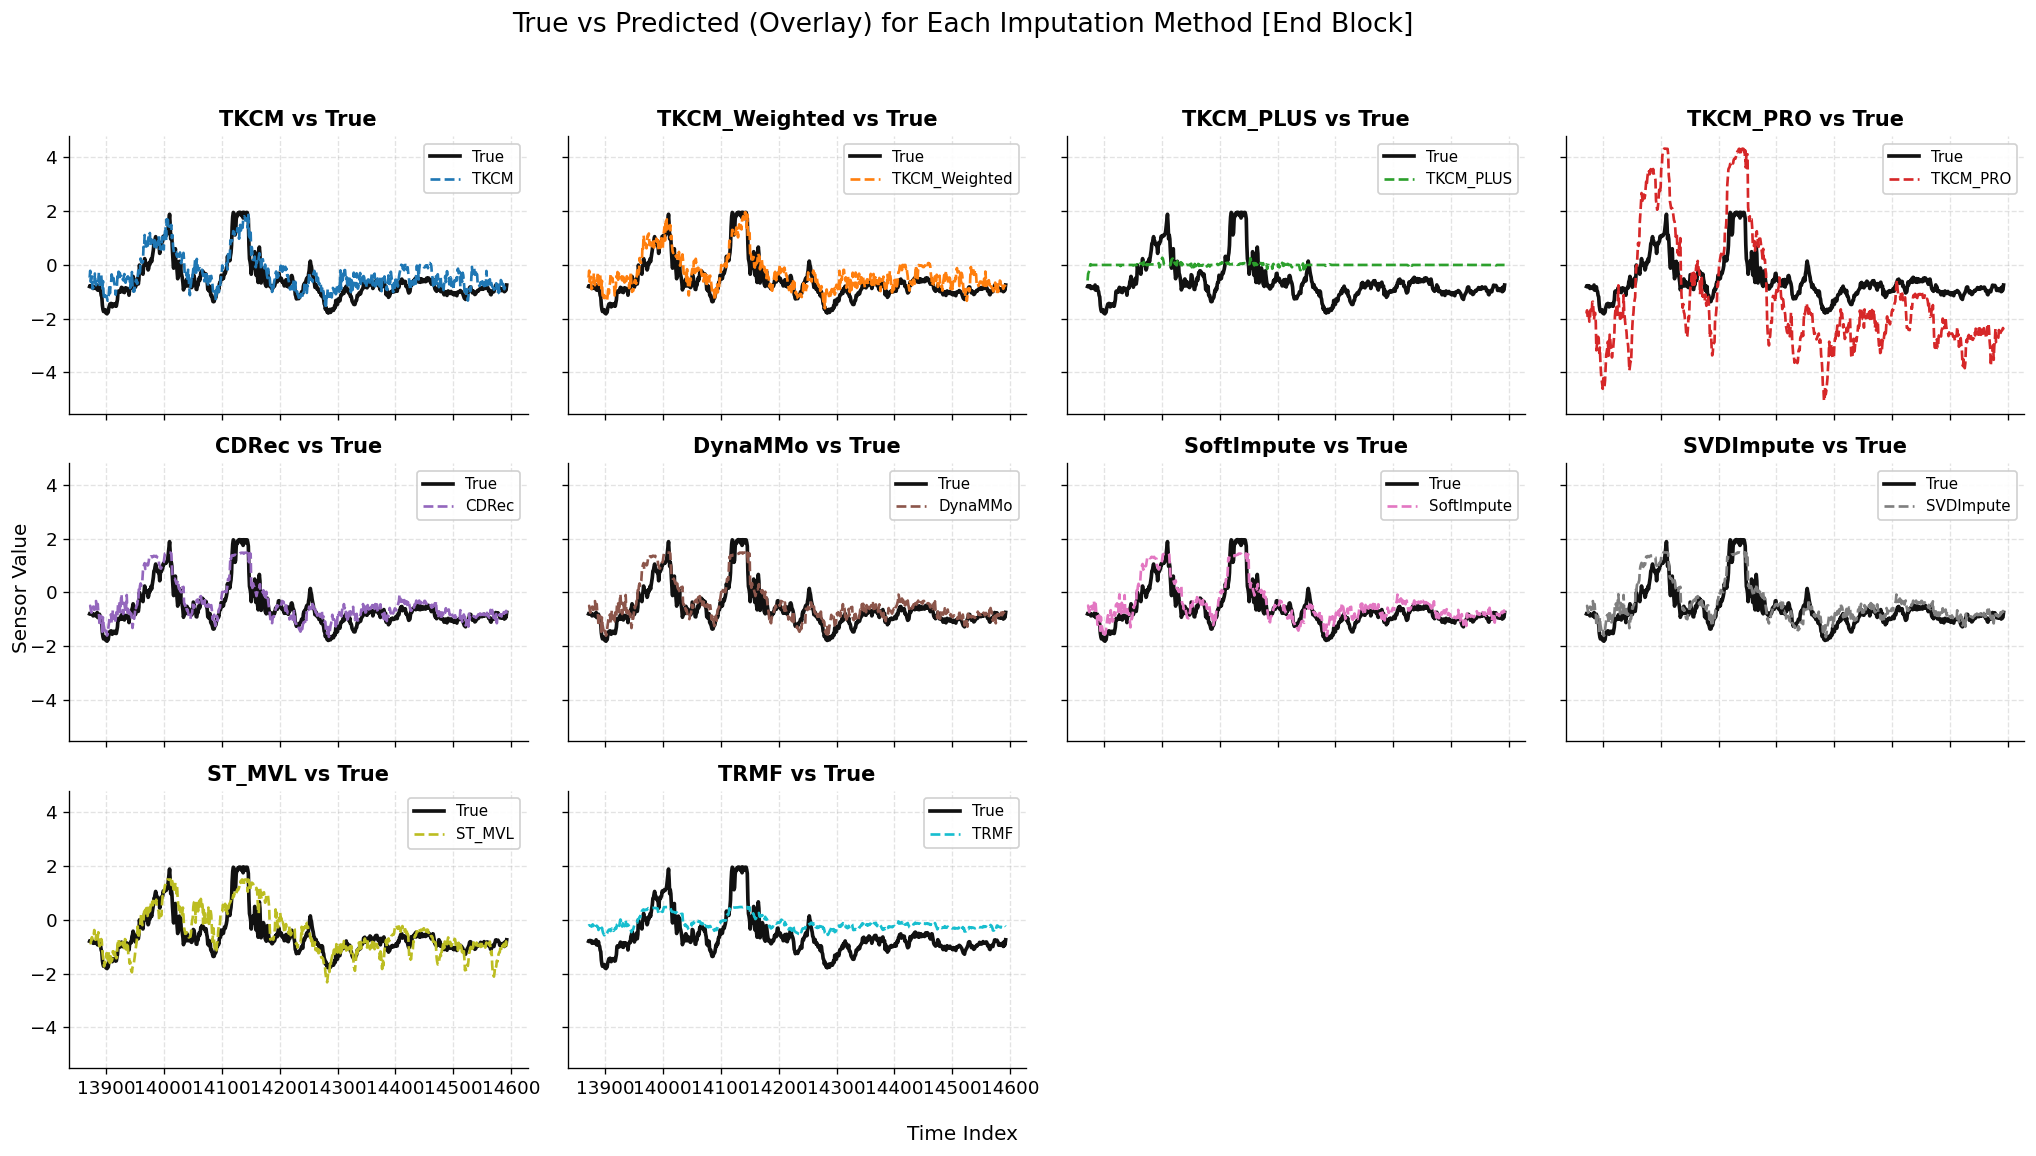

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt

# ==== choose methods & order (match your screenshot order) ====
methods = [
    "TKCM",
    "TKCM_Weighted",
    "TKCM_PLUS",
    "TKCM_PRO",
    "CDRec",
    "DynaMMo",
    "SoftImpute",
    "SVDImpute",
    "ST_MVL",
    "TRMF",
]

# map names to your arrays
series_map = {
    "TKCM": tkcm_imputed,
    "TKCM_Weighted": tkcm_weighted_imputed,
    "TKCM_PLUS": tkcm_plus_imputed,
    "TKCM_PRO": tkcm_pro_imputed,
    "CDRec": cdrec_imputed,
    "DynaMMo": dynammo_imputed,
    "SoftImpute": soft_imputed,
    "SVDImpute": svd_imputed,
    "ST_MVL": st_mvl_imputed,
    "TRMF": trmf_imputed,
}

# ==== slice to the end block ====
i0, i1 = start_idx, end_idx
t_block = np.arange(i0, i1)
true_block = np.asarray(true_target_array)[i0:i1]
block_map = {m: np.asarray(series_map[m])[i0:i1] for m in methods}

# ==== styling ====
palette = [
    "#1f77b4","#ff7f0e","#2ca02c","#d62728","#9467bd",
    "#8c564b","#e377c2","#7f7f7f","#bcbd22","#17becf"
]

# ==== grid figure (3 x 4) like the sample ====
rows, cols = 3, 4
fig, axes = plt.subplots(rows, cols, figsize=(18, 10), sharex=True, sharey=True)
axes = axes.flatten()

for i, method in enumerate(methods):
    ax = axes[i]
    ax.plot(t_block, true_block, color="#111111", linewidth=2.2, label="True")
    ax.plot(t_block, block_map[method],
            linestyle="--", linewidth=1.6, color=palette[i % len(palette)],
            label=method)
    ax.set_title(f"{method} vs True", fontsize=12.5)
    ax.grid(True, linestyle="--", alpha=0.35)
    ax.legend(loc="upper right", fontsize=9, frameon=True, framealpha=0.9)

# remove unused panels
for j in range(len(methods), rows*cols):
    fig.delaxes(axes[j])

# global labels + tidy look
for spine in ("top","right"):
    [ax.spines[spine].set_visible(False) for ax in fig.axes if hasattr(ax, "spines")]

fig.suptitle("True vs Predicted (Overlay) for Each Imputation Method [End Block]", fontsize=16, y=0.98)
fig.text(0.5, 0.04, "Time Index", ha="center", fontsize=12)
fig.text(0.06, 0.5, "Sensor Value", va="center", rotation="vertical", fontsize=12)

fig.tight_layout(rect=[0.06, 0.06, 1, 0.95])
os.makedirs("plots", exist_ok=True)
fig.savefig("plots/valley_end_block_overlays.pdf")
fig.savefig("plots/valley_end_block_overlays.png", dpi=300)
plt.show(); plt.close(fig)


🔄 Enhanced Logic Summary:
- When imputing a missing value in the target series, combine:
- The reference time series (as in original TKCM)
- The past values in the same target series, up to but not including the missing value (i.e. before the offset)

-> ✅ What I’ll Do in TKCM_PLUS:
- Still use the sliding-window approach and dynamic programming to find top-k similar patterns in the reference series.
- Then enhance each distance computation by also comparing the candidate window with the past known values of the target.
- The distance formula becomes a hybrid dissimilarity:
- distance = alpha * distance_with_ref + beta * distance_with_target_past
- I can set alpha and beta (e.g., both 0.5) to weight how much to rely on external reference vs internal target pattern.

📌 Notes:
   ------
- The new class TKCM_PLUS allows us to control the balance with alpha (ref series) and beta (target’s past).
- tkcm still assume only one NaN in the target per call.
- It preserves the original logic and adds extra pattern context for robustness.


✅ TKCM_PRO – Use Summed Reference Series
🔧 What changes in TKCM_PRO?
-> we still slide over the reference matrix to find the top-k similar windows.
- But when imputing, instead of:
- using each individual reference series separately (as in original TKCM),
we:
- sum up the values across all reference series (i.e., row-wise sum at each mod(pos, L))
- then average those summed values for top-k matches.

In [53]:
# 📈 Line Chart (MAE & RMSE)
import plotly.graph_objects as go

fig = go.Figure()
fig.add_trace(go.Scatter(x=results_df["Method"], y=results_df["MAE"], mode='lines+markers', name='MAE'))
fig.add_trace(go.Scatter(x=results_df["Method"], y=results_df["RMSE"], mode='lines+markers', name='RMSE'))

fig.update_layout(title="Line Plot: MAE & RMSE by Method", xaxis_title="Method", yaxis_title="Error")
fig.show()


In [54]:
# 🌊 Area Chart (Stacked MAE & RMSE)

fig = go.Figure()
fig.add_trace(go.Scatter(x=results_df["Method"], y=results_df["MAE"], fill='tozeroy', name='MAE'))
fig.add_trace(go.Scatter(x=results_df["Method"], y=results_df["RMSE"], fill='tonexty', name='RMSE'))

fig.update_layout(title="Area Chart: MAE and RMSE", xaxis_title="Method", yaxis_title="Error")
fig.show()

In [55]:
# 🧱 Waterfall Chart (MAE)

fig = go.Figure(go.Waterfall(
    x=results_df["Method"],
    y=results_df["MAE"],
    measure=["relative"] * len(results_df),
    text=results_df["MAE"].round(2),
    name="MAE"
))

fig.update_layout(title="Waterfall Chart: MAE Differences Across Methods", xaxis_title="Method", yaxis_title="MAE")
fig.show()

In [56]:
#🌲 Treemap (MAE & RMSE Combined Size)

import numpy as np

fig = go.Figure(go.Treemap(
    labels=results_df["Method"],
    parents=[""] * len(results_df),
    values=np.sqrt(results_df["MAE"]**2 + results_df["RMSE"]**2),  # Combined magnitude
    text=[f"MAE: {mae}<br>RMSE: {rmse}" for mae, rmse in zip(results_df["MAE"], results_df["RMSE"])],
    hoverinfo="label+text+value"
))
fig.update_layout(title="Treemap: Method Error Magnitude (MAE & RMSE)")
fig.show()

In [57]:
import plotly.graph_objects as go
import numpy as np
import plotly.io as pio

# ✅ Ensure kaleido is installed for static export
# pip install -U kaleido

fig = go.Figure(go.Treemap(
    labels=results_df["Method"],
    parents=[""] * len(results_df),
    values=np.sqrt(results_df["MAE"]**2 + results_df["RMSE"]**2),  # Combined magnitude
    text=[f"MAE: {mae}<br>RMSE: {rmse}" for mae, rmse in zip(results_df["MAE"], results_df["RMSE"])],
    hoverinfo="label+text+value"
))
fig.update_layout(title="Treemap: Method Error Magnitude (MAE & RMSE)")

# 📁 Create output folder
import os
os.makedirs("plots", exist_ok=True)

# 1️⃣ Save static high-res PNG & PDF
fig.write_image("plots/treemap_error_magnitude.png", scale=3)   # PNG
fig.write_image("plots/treemap_error_magnitude.pdf")            # PDF (vector)

# 2️⃣ Save interactive HTML
fig.write_html("plots/treemap_error_magnitude.html")

print("✅ Treemap saved as PNG, PDF, and HTML in 'plots/' folder.")


✅ Treemap saved as PNG, PDF, and HTML in 'plots/' folder.


In [58]:
#🔻 Funnel Pyramid (Descending MAE)

import plotly.graph_objects as go

# Sort by MAE descending
sorted_df = results_df.sort_values(by="MAE", ascending=False)

# Make sure MAE is numeric
sorted_df["MAE"] = pd.to_numeric(sorted_df["MAE"], errors="coerce")

# Create Funnelarea chart
fig = go.Figure(go.Funnelarea(
    labels=sorted_df["Method"],
    values=sorted_df["MAE"],
    textinfo="label+value+percent"  # ✅ valid format
))

fig.update_layout(title="Funnel Pyramid: MAE Distribution")
fig.show()
